# Notebook 03: EfficientNet-B0 Two-Stage ABMIL Training
**Goal:** Stage 1 pre-trains the backbone on patch-level classification. 
Stage 2 freezes the backbone, caches features, and trains the ABMIL 
attention head for bag-level (mammogram-level) prediction.

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

# Environment check 
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"timm     : {timm.__version__}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
timm     : 1.0.26
GPU      : Tesla T4


## 1. Paths and Config
All input/output paths defined once here. All tunable hyperparameters 
in one block.

In [2]:
NB02 = Path(
    "/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction"
)
OUT  = Path("/kaggle/working")

# Input files from NB02
X_TRAIN_PATH        = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH        = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH  = NB02 / "bag_ids_train.npy"
TRAIN_BAG_IDX_PATH  = NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH    = NB02 / "val_bag_indices.npy"
CLASS_WEIGHTS_PATH  = NB02 / "class_weights.json"

X_TEST_PATH         = NB02 / "X_test_patches.npy"
Y_TEST_PATH         = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH   = NB02 / "bag_ids_test.npy"

# Output files
S1_WEIGHTS   = OUT / "efficientnet_b0_stage1.pth"
S2_WEIGHTS   = OUT / "efficientnet_b0_stage2.pth"
RESULTS_JSON = OUT / "efficientnet_b0_results.json"

print("NB02 path exists:", NB02.exists())
print("Output dir      :", OUT)

NB02 path exists: True
Output dir      : /kaggle/working


In [3]:
MODEL_NAME   = "efficientnet_b0"
FEAT_DIM     = 1280          # confirmed from NB02 verification
ATTN_DIM     = 128

PATCH_SIZE   = 224
SEED         = 42

# Stage 1: patch level
BS_STAGE1    = 128           # patches are small, large batch fine
LR_STAGE1    = 1e-3
EPOCHS_S1    = 15
PATIENCE_S1  = 5

# Stage 2: bag level (backbone frozen, feature cache used)
LR_S2_HEAD   = 1e-4
EPOCHS_S2    = 30
PATIENCE_S2  = 7

# ImageNet normalisation stats (applied after 0-1 rescaling)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

Device: cuda


In [4]:
import sys
sys.path.append('/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config')
from abmil_common import (
    build_backbone, PatchDataset, PatchClassifier,
    AttentionPool, BagClassifier, CachedBagDataset, collate_cached,
    extract_features, compute_all_metrics, get_normalisation_tensors,
)
_mean_gpu, _std_gpu = get_normalisation_tensors(DEVICE)

## 2. Load NB02 Outputs
Load patch arrays, bag IDs, patient-level split indices, and class 
weights. Zero patient overlap between train and val is verified here.

In [5]:
print("Loading arrays...")
X_train_all  = np.load(X_TRAIN_PATH)   
y_train_all  = np.load(Y_TRAIN_PATH)  
bag_ids_all  = np.load(BAG_IDS_TRAIN_PATH)  

train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)  
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)    

X_test_all   = np.load(X_TEST_PATH)   
y_test_all   = np.load(Y_TEST_PATH)    
bag_ids_test = np.load(BAG_IDS_TEST_PATH)  

with open(CLASS_WEIGHTS_PATH) as f:
    raw_cw = json.load(f)
class_weight_dict = {int(k): float(v) for k, v in raw_cw.items()}

# Checks 
print("\n── Train arrays ──")
print(f"X_train_all : {X_train_all.shape}  dtype={X_train_all.dtype}"
      f"  range=[{X_train_all.min():.3f}, {X_train_all.max():.3f}]")
print(f"y_train_all : {y_train_all.shape}  "
      f"benign={( y_train_all==0).sum()}  "
      f"malignant={(y_train_all==1).sum()}")
print(f"bag_ids_all : {bag_ids_all.shape}  "
      f"unique bags={len(np.unique(bag_ids_all))}")

print("\n── Split indices ──")
print(f"train_bag_indices : {train_bag_indices.shape}")
print(f"val_bag_indices   : {val_bag_indices.shape}")
overlap = set(train_bag_indices) & set(val_bag_indices)
print(f"Patient overlap   : {len(overlap)}  (must be 0)")

print("\n── Test arrays ──")
print(f"X_test_all : {X_test_all.shape}")
print(f"y_test_all : {y_test_all.shape}  "
      f"benign={(y_test_all==0).sum()}  "
      f"malignant={(y_test_all==1).sum()}")

print("\n── Class weights ──")
print(class_weight_dict)

Loading arrays...

── Train arrays ──
X_train_all : (19770, 224, 224, 1)  dtype=float32  range=[0.000, 1.000]
y_train_all : (19770,)  benign=13616  malignant=6154
bag_ids_all : (19770,)  unique bags=1318

── Split indices ──
train_bag_indices : (1061,)
val_bag_indices   : (257,)
Patient overlap   : 0  (must be 0)

── Test arrays ──
X_test_all : (5997, 224, 224, 1)
y_test_all : (5997,)  benign=4620  malignant=1377

── Class weights ──
{0: 0.7259841363102233, 1: 1.6062723431914203}


## 3. Apply Patient-Level Split
Use precomputed bag indices from NB02 to mask patches into train/val. 
No data is re-split here. Indices are loaded, not recomputed.

In [6]:
train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_tr     = X_train_all[train_mask]
y_tr     = y_train_all[train_mask]
bag_tr   = bag_ids_all[train_mask]

X_val    = X_train_all[val_mask]
y_val    = y_train_all[val_mask]
bag_val  = bag_ids_all[val_mask]

print("After split")
print(f"Train patches : {X_tr.shape}  "
      f"benign={(y_tr==0).sum()}  malignant={(y_tr==1).sum()}")
print(f"Val   patches : {X_val.shape}  "
      f"benign={(y_val==0).sum()}  malignant={(y_val==1).sum()}")
print(f"Train bags    : {len(np.unique(bag_tr))}")
print(f"Val   bags    : {len(np.unique(bag_val))}")

After split
Train patches : (16198, 224, 224, 1)  benign=11356  malignant=4842
Val   patches : (3572, 224, 224, 1)  benign=2260  malignant=1312
Train bags    : 1061
Val   bags    : 257


## 4. Preprocessing Pipeline
Patches arrive as (N, 224, 224, 1) float32 in [0,1]. Expanded to 3 
channels and ImageNet-normalised here. Normalisation is model-specific 
so it lives in NB03, not NB02.

In [ ]:
# _mean = torch.tensor(IMAGENET_MEAN, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
# _std  = torch.tensor(IMAGENET_STD,  dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)

# def numpy_to_tensor(X_np: np.ndarray) -> torch.Tensor:
#     t = torch.from_numpy(X_np).float()       
#     t = t.permute(0, 3, 1, 2)                  
#     t = t.repeat(1, 3, 1, 1)                 
#     t = t.to(DEVICE)
#     t = (t - _mean) / _std
#     return t

# # Quick test 
# _test = numpy_to_tensor(X_tr[:4])
# print("Preprocess test:", _test.shape, _test.dtype,
#       f"mean≈{_test.mean().item():.3f}")
# del _test

## 5. Dataset Classes
Three dataset classes serve different stages:
- `PatchDataset`: flat patch array for Stage 1 patch classification
- `BagDataset`: groups patches by bag ID (not used in this notebook)
- `CachedBagDataset`: groups pre-extracted feature vectors by bag ID; 
  used in Stage 2 because the backbone is frozen

In [ ]:
# _mean_gpu = torch.tensor(IMAGENET_MEAN, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
# _std_gpu  = torch.tensor(IMAGENET_STD,  dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)

# class PatchDataset(Dataset):
#     def __init__(self, X_np: np.ndarray, y_np: np.ndarray):
#         self.X = X_np
#         self.y = torch.from_numpy(y_np).float()

#     def __len__(self):
#         return len(self.y)

#     def __getitem__(self, idx):
#         # Simply hand over the single-channel patch to the DataLoader
#         patch = self.X[idx]                       
#         patch = torch.from_numpy(patch).float()     
#         return patch.permute(2, 0, 1), self.y[idx]  

In [ ]:
# # Stage 2 Dataset
# class BagDataset(Dataset):
#     def __init__(self,
#                  X_np:      np.ndarray,
#                  y_np:      np.ndarray,
#                  bag_ids:   np.ndarray,
#                  bag_list:  np.ndarray):
#         self.X        = X_np
#         self.y        = y_np
#         self.bag_ids  = bag_ids
#         self.bag_list = bag_list

#     def __len__(self):
#         return len(self.bag_list)

#     def __getitem__(self, idx):
#         bid   = self.bag_list[idx]
#         mask  = self.bag_ids == bid
#         patches = self.X[mask]           
#         labels  = self.y[mask]          

#         t = torch.from_numpy(patches).float()  
#         t = t.permute(0, 3, 1, 2)              
#         t = t.repeat(1, 3, 1, 1)                
        
#         # Variable-size adjustments for normalisation tensors on CPU
#         m = _mean_cpu.unsqueeze(0)   # (1, 3, 1, 1)
#         s = _std_cpu.unsqueeze(0)    # (1, 3, 1, 1)
#         t = (t - m) / s

#         bag_label = torch.tensor(labels[0], dtype=torch.float32)
#         return t, bag_label

GPU Strategy for Stage 2:
- Precompute backbone features ONCE for all patches
- Store as (N, FEAT_DIM) tensor
- Stage 2 training loop iterates over cached features only
- Backbone makes zero forward passes per epoch after caching

In [ ]:
# class CachedBagDataset(Dataset):
#     def __init__(self,
#                  features:  np.ndarray,
#                  y_np:      np.ndarray,
#                  bag_ids:   np.ndarray,
#                  bag_list:  np.ndarray):
#         self.features  = features
#         self.y         = y_np
#         self.bag_ids   = bag_ids
#         self.bag_list  = bag_list

#     def __len__(self):
#         return len(self.bag_list)

#     def __getitem__(self, idx):
#         bid  = self.bag_list[idx]
#         mask = self.bag_ids == bid
        
#         # Safely creates a CPU tensor from pre-computed features array
#         h    = torch.from_numpy(self.features[mask]).float()    
        
#         bag_label = torch.tensor(
#                         self.y[mask][0],
#                         dtype=torch.float32)
#         return h, bag_label


# def collate_cached(batch):
#     features_list = [item[0] for item in batch]
#     labels        = torch.stack([item[1] for item in batch])
#     return features_list, labels

## 6. Model Architecture

### 6a. Backbone
EfficientNet-B0 loaded via `timm` with `num_classes=0`removes the 
classifier head and returns a flat 1280-dim feature vector after GAP.

In [7]:
# def build_backbone(model_name: str,
#                    pretrained: bool = True) -> nn.Module:
#     model = timm.create_model(
#         model_name,
#         pretrained=pretrained,
#         num_classes=0        # removes classifier head, keeps GAP
#     )
#     return model

backbone = build_backbone(MODEL_NAME, pretrained=True)
backbone = backbone.to(DEVICE)

# Confirms feature dimension 
with torch.no_grad():
    _dummy = torch.zeros(2, 3, PATCH_SIZE, PATCH_SIZE,
                         device=DEVICE)
    _out   = backbone(_dummy)
    print(f"Backbone output shape : {_out.shape}")
    print(f"Expected FEAT_DIM     : {FEAT_DIM}")
    assert _out.shape[1] == FEAT_DIM, (
        f"Feature dim mismatch: got {_out.shape[1]}, "
        f"expected {FEAT_DIM}"
    )
del _dummy, _out
print("Backbone verified.")

Backbone output shape : torch.Size([2, 1280])
Expected FEAT_DIM     : 1280
Backbone verified.


### 6b. Stage 1: Patch Classifier
Backbone + single linear head for binary patch classification. 
No sigmoid in forward pass: `BCEWithLogitsLoss` handles it for 
numerical stability.

In [ ]:
# class PatchClassifier(nn.Module):
#     def __init__(self, backbone: nn.Module, feat_dim: int):
#         super().__init__()
#         self.backbone = backbone
#         self.head     = nn.Linear(feat_dim, 1)

#     def forward(self, x):
#         h   = self.backbone(x)   
#         out = self.head(h)        
#         return out.squeeze(1)    

### 6c. ABMIL Attention Head (Ilse et al., 2018)
Computes a weighted sum of patch features as the bag representation:  
`a_k = softmax(wᵀ tanh(V hₖ))` across all patches k,  
`z = Σ aₖ hₖ`  
Attention weights are returned so they can be visualised post-hoc.

In [ ]:
# class AttentionPool(nn.Module):
#     def __init__(self, feat_dim: int, attn_dim: int):
#         super().__init__()
#         self.V = nn.Linear(feat_dim, attn_dim, bias=True)
#         self.w = nn.Linear(attn_dim, 1,        bias=False)

#     def forward(self, h: torch.Tensor):
#         a = self.w(torch.tanh(self.V(h)))  # (N, 1) raw scores
#         a = torch.softmax(a, dim=0)        # (N, 1) normalised
#         z = torch.sum(a * h, dim=0, keepdim=True)  # (1, feat_dim)
#         return z, a

### 6d. Stage 2: Bag Classifier
AttentionPool + linear head operating on cached features only. 
Backbone is not included here. Zero backbone forward passes per 
Stage 2 epoch.

In [ ]:
# class BagClassifier(nn.Module):
#     def __init__(self, feat_dim: int, attn_dim: int):
#         super().__init__()
#         self.attn = AttentionPool(feat_dim, attn_dim)
#         self.head = nn.Linear(feat_dim, 1)

#     def forward(self, h: torch.Tensor):
#         z, a  = self.attn(h)        # z: (1, feat_dim)
#         logit = self.head(z)        # (1, 1)
#         return logit.squeeze(), a

## 7. Stage 1 Training: Patch-Level Pre-training
`pos_weight` derived from class weight ratio corrects for the 2.2:1 
benign:malignant patch imbalance. AMP (mixed precision) reduces VRAM usage.

In [8]:
patch_model = PatchClassifier(backbone, FEAT_DIM).to(DEVICE)

pos_weight_val = class_weight_dict[1] / class_weight_dict[0]
criterion_s1   = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_val, device=DEVICE)
)
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight_val:.4f}")

optimiser_s1  = optim.Adam(patch_model.parameters(), lr=LR_STAGE1)
scheduler_s1  = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s1, mode='min', factor=0.5,
    patience=3
)

train_patch_ds = PatchDataset(X_tr,  y_tr)
val_patch_ds   = PatchDataset(X_val, y_val)

train_patch_dl = DataLoader(train_patch_ds, batch_size=BS_STAGE1,
                             shuffle=True,  num_workers=2,
                             pin_memory=True)
val_patch_dl   = DataLoader(val_patch_ds,   batch_size=BS_STAGE1,
                             shuffle=False, num_workers=2,
                             pin_memory=True)

print(f"Train batches : {len(train_patch_dl)}")
print(f"Val   batches : {len(val_patch_dl)}")

pos_weight for BCEWithLogitsLoss: 2.2125
Train batches : 127
Val   batches : 28


### 7a. Training Loop
Early stopping on val loss with patience=5. Best weights saved to disk.

In [9]:
scaler = torch.amp.GradScaler('cuda')

s1_history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
best_val_loss_s1    = float("inf")
patience_counter_s1 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S1 + 1):
    patch_model.train()
    running_loss = 0.0
    for patches, labels in train_patch_dl:
        # 1. Push raw single-channel patches to GPU memory immediately
        patches, labels = patches.to(DEVICE), labels.to(DEVICE) 
        
        # 2. Parallelised channel expansion and normalisation on GPU cores
        patches = patches.repeat(1, 3, 1, 1)              
        patches = (patches - _mean_gpu) / _std_gpu             
        
        optimiser_s1.zero_grad()
        
        # 3. Forward pass wrapped in AMP autocast to optimise VRAM
        with torch.amp.autocast('cuda'):
            logits = patch_model(patches)
            loss = criterion_s1(logits, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimiser_s1)
        scaler.update()
        
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_patch_dl.dataset)

    # Validation Phase
    patch_model.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for patches, labels in val_patch_dl:
            patches, labels = patches.to(DEVICE), labels.to(DEVICE)

            patches = patches.repeat(1, 3, 1, 1)
            patches = (patches - _mean_gpu) / _std_gpu
            
            with torch.amp.autocast('cuda'):
                logits   = patch_model(patches)
                loss_val = criterion_s1(logits, labels)
                
            val_loss += loss_val.item() * len(labels)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    val_loss  /= len(val_patch_dl.dataset)
    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    val_preds  = (all_probs >= 0.5).astype(int)
    val_auc    = roc_auc_score(all_labels, all_probs)
    val_f1     = f1_score(all_labels, val_preds, zero_division=0)

    s1_history["train_loss"].append(train_loss)
    s1_history["val_loss"].append(val_loss)
    s1_history["val_auc"].append(val_auc)
    s1_history["val_f1"].append(val_f1)
    scheduler_s1.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S1}  "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_auc={val_auc:.4f}  val_f1={val_f1:.4f}")

    if val_loss < best_val_loss_s1:
        best_val_loss_s1    = val_loss
        patience_counter_s1 = 0
        torch.save(patch_model.state_dict(), S1_WEIGHTS)
        print("  ✓ Saved best Stage 1 weights")
    else:
        patience_counter_s1 += 1
        if patience_counter_s1 >= PATIENCE_S1:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 1 complete : {(time.time()-t0)/60:.1f} min")

Ep 01/15  train_loss=0.6586  val_loss=0.7079  val_auc=0.8094  val_f1=0.6804
  ✓ Saved best Stage 1 weights
Ep 02/15  train_loss=0.6152  val_loss=0.7360  val_auc=0.8160  val_f1=0.6829
Ep 03/15  train_loss=0.5832  val_loss=0.7124  val_auc=0.8180  val_f1=0.6972
Ep 04/15  train_loss=0.5587  val_loss=0.8186  val_auc=0.7753  val_f1=0.6448
Ep 05/15  train_loss=0.5249  val_loss=0.7645  val_auc=0.7950  val_f1=0.6680
Ep 06/15  train_loss=0.4115  val_loss=0.8769  val_auc=0.8114  val_f1=0.6815
  Early stopping at epoch 6

Stage 1 complete : 4.6 min


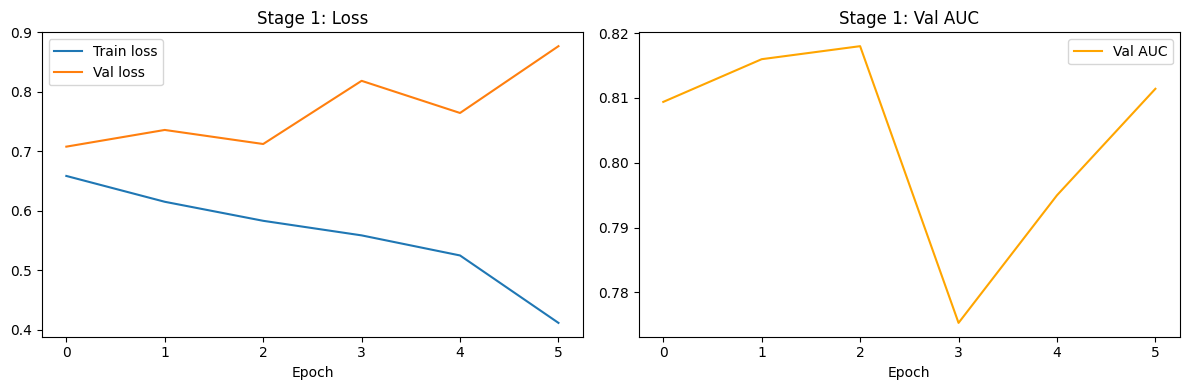

Saved stage1_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s1_history["train_loss"], label="Train loss")
axes[0].plot(s1_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 1: Loss"); axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(s1_history["val_auc"], label="Val AUC", color="orange")
axes[1].set_title("Stage 1: Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUT / "stage1_training_curves.png", dpi=150)
plt.show()
print("Saved stage1_training_curves.png")

### 7b. Stage 1 Diagnostics
Reload best weights and compute patch-level AUC, F1, sensitivity, 
and specificity on the val set.

In [11]:
# Stage 1 patch-level diagnostic metrics
patch_model.load_state_dict(
    torch.load(S1_WEIGHTS, map_location=DEVICE))
patch_model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for patches, labels in val_patch_dl:
        patches = patches.to(DEVICE)
        
        patches = patches.repeat(1, 3, 1, 1)
        patches = (patches - _mean_gpu) / _std_gpu
        
        with torch.amp.autocast('cuda'):
            all_probs.extend(
                torch.sigmoid(patch_model(patches)).cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
preds      = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

s1_metrics = {
    "patch_auc"        : float(roc_auc_score(all_labels, all_probs)),
    "patch_f1"         : float(f1_score(all_labels, preds, zero_division=0)),
    "patch_sensitivity": float(recall_score(all_labels, preds, zero_division=0)),
    "patch_specificity": float(tn / (tn + fp)),
}
print("Stage 1 Patch-Level Val Metrics")
for k, v in s1_metrics.items():
    print(f"  {k:25s}: {v:.4f}")

Stage 1 Patch-Level Val Metrics
  patch_auc                : 0.8094
  patch_f1                 : 0.6804
  patch_sensitivity        : 0.5671
  patch_specificity        : 0.9420


## 8. Feature Caching
Backbone frozen and used to extract features for all train, val, and 
test patches in one pass. Stage 2 training then operates on 
(N, 1280) arrays. No image loading per epoch.

In [12]:
# Use backbone from patch_model (already loaded with best S1 weights)
feature_extractor = patch_model.backbone
feature_extractor.eval()
for p in feature_extractor.parameters():
    p.requires_grad_(False)

# def extract_features(X_np: np.ndarray,
#                      model: nn.Module,
#                      batch_size: int = 256) -> np.ndarray:
#     all_feats = []
#     n = len(X_np)
#     model.eval()
#     with torch.no_grad():
#         for start in range(0, n, batch_size):
#             batch = X_np[start : start + batch_size]
#             t     = numpy_to_tensor(batch)         
#             feats = model(t).cpu().numpy()          
#             all_feats.append(feats)
#     return np.concatenate(all_feats, axis=0)

print("Extracting train features...")
feats_tr  = extract_features(X_tr, feature_extractor, _mean_gpu, _std_gpu, DEVICE)
print(f"  train : {feats_tr.shape}")

print("Extracting val features...")
feats_val = extract_features(X_val, feature_extractor, _mean_gpu, _std_gpu, DEVICE)
print(f"  val   : {feats_val.shape}")

print("Extracting test features...")
feats_test = extract_features(X_test_all, feature_extractor, _mean_gpu, _std_gpu, DEVICE)
print(f"  test  : {feats_test.shape}")

Extracting train features...
  train : (16198, 1280)
Extracting val features...
  val   : (3572, 1280)
Extracting test features...
  test  : (5997, 1280)


## 9. Stage 2 Training: Bag-Level ABMIL
Attention head trained on cached features. No `pos_weight` here. Loss is at bag level where class balance is closer to 1:1.

In [13]:
bag_model = BagClassifier(FEAT_DIM, ATTN_DIM).to(DEVICE)

criterion_s2  = nn.BCEWithLogitsLoss()


optimiser_s2  = optim.Adam(bag_model.parameters(),
                            lr=LR_S2_HEAD)
scheduler_s2  = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser_s2, mode='min', factor=0.5,
    patience=3
)

# Bag-level labels (one per bag, from patch labels)
def get_bag_labels(y_np: np.ndarray,
                   bag_ids: np.ndarray,
                   bag_list: np.ndarray) -> np.ndarray:
    bag_labels = {}
    for bid in bag_list:
        mask = bag_ids == bid
        bag_labels[bid] = int(y_np[mask][0])
    return np.array([bag_labels[b] for b in bag_list])

train_bag_labels = get_bag_labels(y_tr,  bag_tr,  train_bag_indices)
val_bag_labels   = get_bag_labels(y_val, bag_val, val_bag_indices)
test_bag_labels  = get_bag_labels(y_test_all, bag_ids_test,
                                   np.unique(bag_ids_test))

# CachedBagDataset uses precomputed features
train_bag_ds = CachedBagDataset(feats_tr,   y_tr,       bag_tr,
                                 train_bag_indices)
val_bag_ds   = CachedBagDataset(feats_val,  y_val,      bag_val,
                                 val_bag_indices)

train_bag_dl = DataLoader(train_bag_ds, batch_size=1,
                           shuffle=True,  collate_fn=collate_cached)
val_bag_dl   = DataLoader(val_bag_ds,   batch_size=1,
                           shuffle=False, collate_fn=collate_cached)

print(f"Train bags : {len(train_bag_ds)}")
print(f"Val   bags : {len(val_bag_ds)}")

Train bags : 1061
Val   bags : 257


In [14]:
s2_history = {"train_loss": [], "val_loss": [],
               "val_auc":   [], "val_f1":   []}
best_val_loss_s2 = float("inf")
patience_counter_s2 = 0
t0 = time.time()

for epoch in range(1, EPOCHS_S2 + 1):

    # Train
    bag_model.train()
    running_loss = 0.0
    for h_list, labels in train_bag_dl:
        h      = h_list[0].to(DEVICE)
        label  = labels[0].to(DEVICE)          
        optimiser_s2.zero_grad()
        logit, _ = bag_model(h)
        loss     = criterion_s2(logit, label)
        loss.backward()
        optimiser_s2.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_bag_ds)

    # Validate 
    bag_model.eval()
    val_loss   = 0.0
    val_probs  = []
    val_true   = []
    with torch.no_grad():
        for h_list, labels in val_bag_dl:
            h     = h_list[0].to(DEVICE)
            label = labels[0].to(DEVICE)
            logit, _ = bag_model(h)
            loss  = criterion_s2(logit, label)
            val_loss += loss.item()
            val_probs.append(torch.sigmoid(logit).item())
            val_true.append(label.item())
    val_loss /= len(val_bag_ds)

    val_probs = np.array(val_probs)
    val_true  = np.array(val_true)
    val_preds = (val_probs >= 0.5).astype(int)
    val_auc   = roc_auc_score(val_true, val_probs)
    val_f1    = f1_score(val_true, val_preds, zero_division=0)

    s2_history["train_loss"].append(train_loss)
    s2_history["val_loss"].append(val_loss)
    s2_history["val_auc"].append(val_auc)
    s2_history["val_f1"].append(val_f1)

    scheduler_s2.step(val_loss)

    print(f"Ep {epoch:02d}/{EPOCHS_S2}  "
          f"train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  "
          f"val_auc={val_auc:.4f}  "
          f"val_f1={val_f1:.4f}")

    if val_loss < best_val_loss_s2:
        best_val_loss_s2 = val_loss
        patience_counter_s2 = 0
        torch.save(bag_model.state_dict(), S2_WEIGHTS)
        print("  ✓ Saved best Stage 2 weights")
    else:
        patience_counter_s2 += 1
        if patience_counter_s2 >= PATIENCE_S2:
            print(f"  Early stopping at epoch {epoch}")
            break

print(f"\nStage 2 complete — {(time.time()-t0)/60:.1f} min")

Ep 01/30  train_loss=0.1083  val_loss=0.1088  val_auc=0.9896  val_f1=0.9643
  ✓ Saved best Stage 2 weights
Ep 02/30  train_loss=0.0244  val_loss=0.1251  val_auc=0.9892  val_f1=0.9677
Ep 03/30  train_loss=0.0166  val_loss=0.1135  val_auc=0.9897  val_f1=0.9643
Ep 04/30  train_loss=0.0138  val_loss=0.1159  val_auc=0.9901  val_f1=0.9751
Ep 05/30  train_loss=0.0141  val_loss=0.1263  val_auc=0.9909  val_f1=0.9751
Ep 06/30  train_loss=0.0091  val_loss=0.1278  val_auc=0.9912  val_f1=0.9751
Ep 07/30  train_loss=0.0088  val_loss=0.1377  val_auc=0.9910  val_f1=0.9751
Ep 08/30  train_loss=0.0083  val_loss=0.1426  val_auc=0.9905  val_f1=0.9751
  Early stopping at epoch 8

Stage 2 complete — 0.3 min


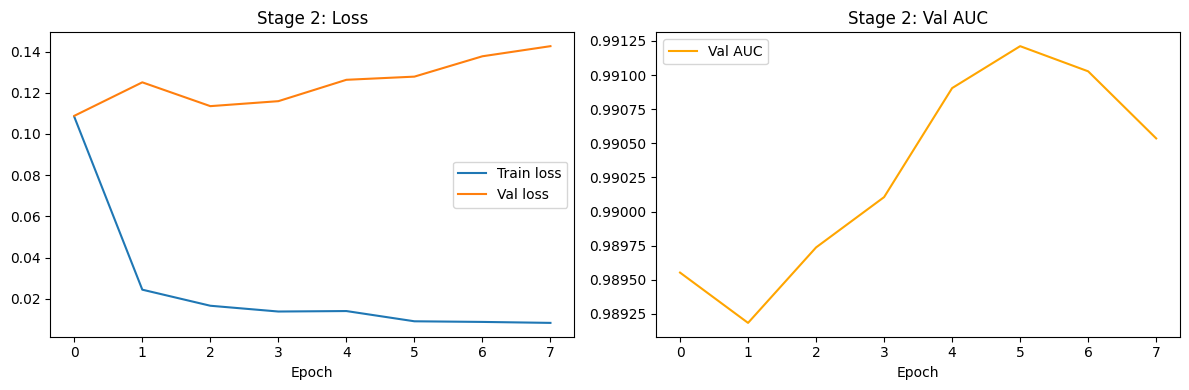

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(s2_history["train_loss"], label="Train loss")
axes[0].plot(s2_history["val_loss"],   label="Val loss")
axes[0].set_title("Stage 2: Loss"); axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(s2_history["val_auc"], label="Val AUC", color="orange")
axes[1].set_title("Stage 2: Val AUC"); axes[1].legend()
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(OUT / "stage2_training_curves.png", dpi=150)
plt.show()

In [16]:
# Load best Stage 2 weights and collect bag-level predictions
bag_model.load_state_dict(torch.load(S2_WEIGHTS,
                           map_location=DEVICE))
bag_model.eval()

val_bag_probs = []
val_bag_true  = []
with torch.no_grad():
    for h_list, labels in val_bag_dl:
        h     = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        val_bag_probs.append(torch.sigmoid(logit).item())
        val_bag_true.append(labels[0].item())

val_bag_probs = np.array(val_bag_probs)
val_bag_true  = np.array(val_bag_true)
print(f"Val bags: {len(val_bag_probs)}")
print(f"Label distribution: benign={( val_bag_true==0).sum()}"
      f"  malignant={(val_bag_true==1).sum()}")

Val bags: 257
Label distribution: benign=113  malignant=144


## 10. Threshold Calibration
Lowest threshold giving sensitivity ≥ 0.90 selected on val set. 
Used consistently for both val and test, not adjusted after 
seeing test results.



90% is a clinical domain standard. In screening mammography, missing a malignancy carries far greater consequences than a false positive, so 90% is a widely cited minimum acceptable sensitivity floor in radiology practice.

In [17]:
fpr_c, tpr_c, thresholds_c = roc_curve(val_bag_true, val_bag_probs)

idx = np.argmax(tpr_c >= 0.90)
optimal_threshold = float(thresholds_c[idx])

print(f"Default threshold (0.5) sensitivity : "
      f"{tpr_c[np.argmin(np.abs(thresholds_c - 0.5))]:.4f}")
print(f"Calibrated threshold                : {optimal_threshold:.4f}")
print(f"Sensitivity at calibrated threshold : {tpr_c[idx]:.4f}")
print(f"FPR at calibrated threshold         : {fpr_c[idx]:.4f}")

Default threshold (0.5) sensitivity : 0.9722
Calibrated threshold                : 0.9882
Sensitivity at calibrated threshold : 0.9097
FPR at calibrated threshold         : 0.0000


In [18]:
def compute_all_metrics(y_true, y_probs, threshold,
                         label="") -> dict:
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # ECE: 10 equal-width bins
    prob_true, prob_pred = calibration_curve(
        y_true, y_probs, n_bins=10, strategy='uniform'
    )
    # Weighted by bin population
    bin_edges = np.linspace(0, 1, 11)
    bin_counts = np.histogram(y_probs, bins=bin_edges)[0]
    ece = float(np.sum(
        bin_counts[:len(prob_true)] *
        np.abs(prob_true - prob_pred)
    ) / len(y_probs))

    metrics = {
        "threshold"   : threshold,
        "auc"         : float(roc_auc_score(y_true, y_probs)),
        "f1"          : float(f1_score(y_true, y_pred,
                                        zero_division=0)),
        "sensitivity" : float(sensitivity),
        "specificity" : float(specificity),
        "fpr"         : float(fpr_val),
        "ece"         : ece,
    }
    if label:
        print(f"── {label} ──")
    for k, v in metrics.items():
        print(f"  {k:15s}: {v:.4f}")
    return metrics

val_metrics_default = compute_all_metrics(
    val_bag_true, val_bag_probs,
    threshold=0.5, label="Val default threshold (0.5)"
)
print()
val_metrics_cal = compute_all_metrics(
    val_bag_true, val_bag_probs,
    threshold=optimal_threshold,
    label=f"Val calibrated threshold ({optimal_threshold:.3f})"
)

── Val default threshold (0.5) ──
  threshold      : 0.5000
  auc            : 0.9896
  f1             : 0.9643
  sensitivity    : 0.9375
  specificity    : 0.9912
  fpr            : 0.0088
  ece            : 0.0171

── Val calibrated threshold (0.988) ──
  threshold      : 0.9882
  auc            : 0.9896
  f1             : 0.9527
  sensitivity    : 0.9097
  specificity    : 1.0000
  fpr            : 0.0000
  ece            : 0.0171


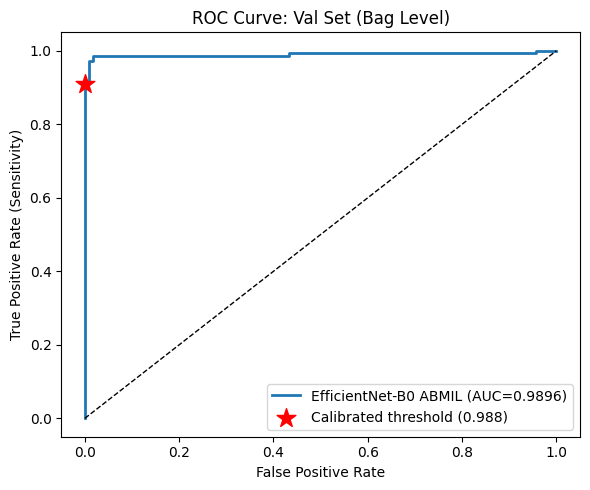

In [19]:
fpr_r, tpr_r, _ = roc_curve(val_bag_true, val_bag_probs)
auc_val = roc_auc_score(val_bag_true, val_bag_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr_r, tpr_r, lw=2,
         label=f"EfficientNet-B0 ABMIL (AUC={auc_val:.4f})")
plt.scatter([fpr_c[idx]], [tpr_c[idx]], marker='*', s=200,
            color='red', zorder=5,
            label=f"Calibrated threshold ({optimal_threshold:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve: Val Set (Bag Level)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "efficientnet_b0_roc_curve.png", dpi=150)
plt.show()

## 11. Test Set Evaluation
Test set is touched exactly once. Threshold was fixed on val above.

In [20]:
test_bag_list = np.unique(bag_ids_test)
test_bag_ds   = CachedBagDataset(feats_test, y_test_all,
                                  bag_ids_test, test_bag_list)
test_bag_dl   = DataLoader(test_bag_ds, batch_size=1,
                            shuffle=False, collate_fn=collate_cached)

test_bag_probs = []
test_bag_true  = []
bag_model.eval()
with torch.no_grad():
    for h_list, labels in test_bag_dl:
        h     = h_list[0].to(DEVICE)
        logit, _ = bag_model(h)
        test_bag_probs.append(torch.sigmoid(logit).item())
        test_bag_true.append(labels[0].item())

test_bag_probs = np.array(test_bag_probs)
test_bag_true  = np.array(test_bag_true)

print()
test_metrics = compute_all_metrics(
    test_bag_true, test_bag_probs,
    threshold=optimal_threshold,
    label=f"Test: calibrated threshold ({optimal_threshold:.3f})"
)


── Test: calibrated threshold (0.988) ──
  threshold      : 0.9882
  auc            : 0.9996
  f1             : 0.9831
  sensitivity    : 0.9864
  specificity    : 0.9870
  fpr            : 0.0130
  ece            : 0.0158


## 12. Attention Weight Visualisation
Attention weights show which patches drove each bag prediction. 
Spatial overlay on the mammogram is not possible because patch 
coordinates were not saved in NB02 (noted as a limitation)

In [21]:
mal_examples = []
ben_examples = []
bag_model.eval()

val_bag_iter = iter(val_bag_dl)
with torch.no_grad():
    for h_list, labels in val_bag_dl:
        if len(mal_examples) >= 4 and len(ben_examples) >= 4:
            break
        h     = h_list[0].to(DEVICE)
        label = int(labels[0].item())
        logit, attn_weights = bag_model(h)
        prob = torch.sigmoid(logit).item()
        entry = {
            "features"     : h.cpu().numpy(),       
            "attn_weights" : attn_weights.cpu().numpy(),  
            "true_label"   : label,
            "pred_prob"    : prob,
        }
        if label == 1 and len(mal_examples) < 4:
            mal_examples.append(entry)
        elif label == 0 and len(ben_examples) < 4:
            ben_examples.append(entry)

print(f"Malignant examples collected: {len(mal_examples)}")
print(f"Benign    examples collected: {len(ben_examples)}")

Malignant examples collected: 4
Benign    examples collected: 4


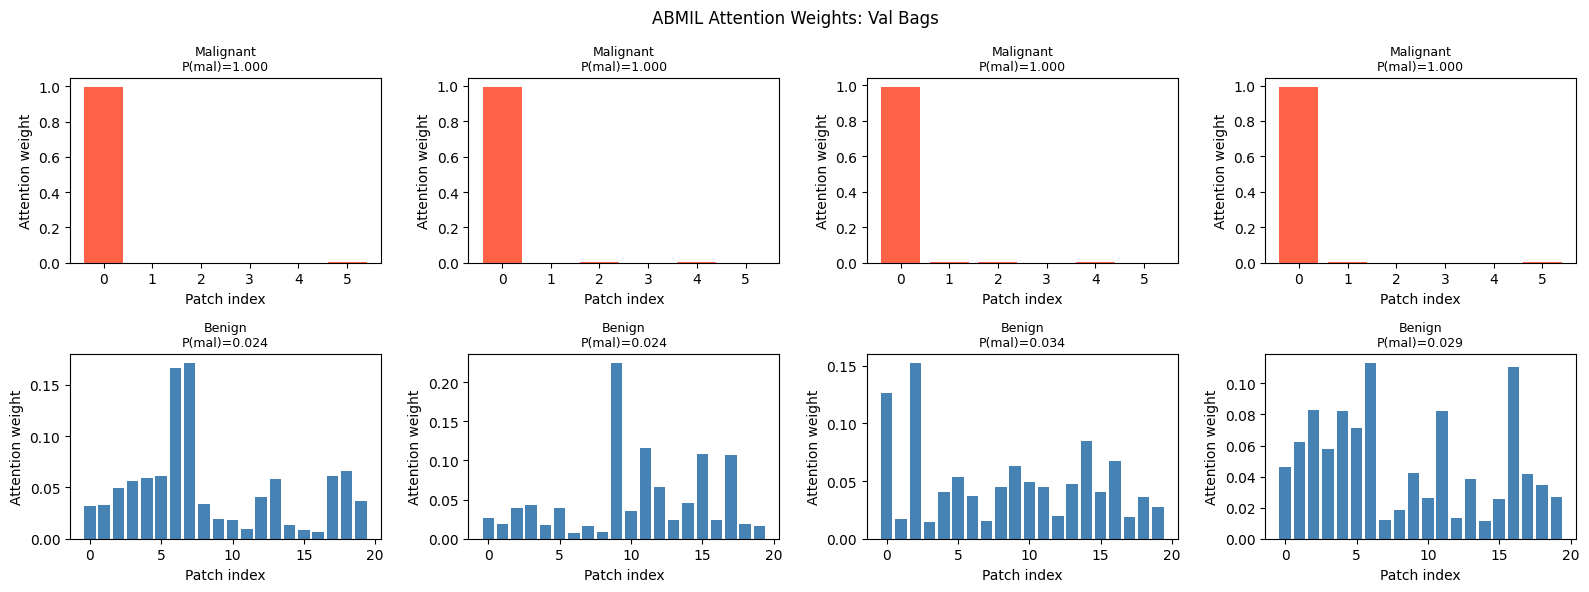

In [22]:
all_examples = mal_examples + ben_examples
n = len(all_examples)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, ex in enumerate(all_examples):
    weights = ex["attn_weights"].squeeze()     # (N_k,)
    label   = "Malignant" if ex["true_label"] == 1 else "Benign"
    prob    = ex["pred_prob"]
    color   = "tomato" if ex["true_label"] == 1 else "steelblue"
    axes[i].bar(range(len(weights)), weights, color=color)
    axes[i].set_title(f"{label}\nP(mal)={prob:.3f}",
                       fontsize=9)
    axes[i].set_xlabel("Patch index")
    axes[i].set_ylabel("Attention weight")

plt.suptitle("ABMIL Attention Weights: Val Bags", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / "attention_examples.png", dpi=150)
plt.show()

## 13. Results Summary

In [23]:
results = {
    "model"              : MODEL_NAME,
    "feat_dim"           : FEAT_DIM,
    "attn_dim"           : ATTN_DIM,
    "stage1_metrics"     : s1_metrics,
    "val_metrics_default": val_metrics_default,
    "val_metrics_cal"    : val_metrics_cal,
    "test_metrics"       : test_metrics,
    "optimal_threshold"  : optimal_threshold,
    "hyperparameters"    : {
        "lr_stage1"   : LR_STAGE1,
        "lr_s2_head"  : LR_S2_HEAD,
        "epochs_s1"   : EPOCHS_S1,
        "epochs_s2"   : EPOCHS_S2,
        "bs_stage1"   : BS_STAGE1,
        "attn_dim"    : ATTN_DIM,
        "patience_s1" : PATIENCE_S1,
        "patience_s2" : PATIENCE_S2,
    }
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_JSON)

Saved: /kaggle/working/efficientnet_b0_results.json


In [24]:
print("=" * 55)
print(f"  NB03 — {MODEL_NAME.upper()} ABMIL — FINAL RESULTS")
print("=" * 55)
print(f"  Stage 1 patch AUC     : "
      f"{s1_metrics['patch_auc']:.4f}")
print(f"  Optimal threshold     : {optimal_threshold:.4f}")
print()
print("  Val set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {val_metrics_cal[k]:.4f}")
print()
print("  Test set (calibrated threshold):")
for k in ["auc","f1","sensitivity","fpr","ece"]:
    print(f"    {k:15s}: {test_metrics[k]:.4f}")
print("=" * 55)

  NB03 — EFFICIENTNET_B0 ABMIL — FINAL RESULTS
  Stage 1 patch AUC     : 0.8094
  Optimal threshold     : 0.9882

  Val set (calibrated threshold):
    auc            : 0.9896
    f1             : 0.9527
    sensitivity    : 0.9097
    fpr            : 0.0000
    ece            : 0.0171

  Test set (calibrated threshold):
    auc            : 0.9996
    f1             : 0.9831
    sensitivity    : 0.9864
    fpr            : 0.0130
    ece            : 0.0158
